In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import json
import os
import mlflow
import mlflow.sklearn
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import seaborn as sns

In [4]:
df = pd.read_csv("../data/master_dataset.csv")
df

,Industry,Stage,Country,Funds_Raised,Cash_Reserves,Profit_Margin,Revenue_Growth,Laid_Off
0,Hardware,Post-IPO,United States,1200.0,9.094300e+10,0.195879,0.045113,0
1,Hardware,Post-IPO,United States,1200.0,7.682600e+10,0.258034,0.722449,0
2,Hardware,Post-IPO,United States,1200.0,6.983400e+10,0.263775,-0.196116,0
3,Hardware,Post-IPO,United States,1200.0,6.169600e+10,0.267014,-0.090976,0
4,Hardware,Post-IPO,United States,1200.0,6.263900e+10,0.246533,0.023651,0
...,...,...,...,...,...,...,...,...
1296,Security,Post-IPO,United States,148.0,1.621209e+09,-0.392936,0.108651,0
1297,Security,Post-IPO,United States,148.0,1.657874e+09,-0.353565,0.122256,0
1298,Security,Post-IPO,United States,148.0,1.731339e+09,-0.307025,0.108965,0
1299,Security,Post-IPO,United States,148.0,1.824790e+09,-0.191710,0.117868,1


In [5]:
X = df.drop(columns=["Laid_Off"])
y = df["Laid_Off"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [6]:
oe = OrdinalEncoder()

col = ["Industry", "Stage", "Country"]

X_train[col] = oe.fit_transform(X_train[col])
X_test[col] = oe.transform(X_test[col])

print(X_train.head(10))

      Industry  Stage  Country  ...  Cash_Reserves  Profit_Margin  Revenue_Growth
601        0.0    0.0      0.0  ...   4.073800e+10       0.144660        0.160605
24        13.0    1.0      0.0  ...   1.014400e+09       0.296124        0.045113
87         2.0    1.0      0.0  ...   3.177630e+08      -0.803972        0.045113
558       23.0    1.0      0.0  ...   1.807048e+09      -0.380769        0.131540
845        0.0    1.0      0.0  ...   3.132964e+09      -0.298253       -0.055620
77        21.0    1.0      0.0  ...   1.098073e+09       0.133962        0.067405
317        0.0    1.0      0.0  ...   2.152892e+09      -0.689372        1.224073
616       15.0    1.0      0.0  ...   1.044270e+11       0.346198        0.002085
530        8.0    1.0      0.0  ...   3.869600e+10       0.442053       -0.105953
1135      15.0    1.0      0.0  ...   6.968410e+08      -0.072662        0.031889

[10 rows x 7 columns]


In [9]:
with open("../models/ordinal_encoder.pkl", "wb") as f:
    pickle.dump(oe,f)

print("\nEncoder saved to models/ordinal_encoder.pkl")
print(f"\nX_train dtypes:\n{X_train.dtypes}")


Encoder saved to models/ordinal_encoder.pkl

X_train dtypes:
Industry          float64
Stage             float64
Country           float64
Funds_Raised      float64
Cash_Reserves     float64
Profit_Margin     float64
Revenue_Growth    float64
dtype: object


In [11]:
best_pipeline = ImbPipeline(steps = [
    ('smote', SMOTE(random_state = 42)),
    ('model', XGBClassifier(
        learning_rate = 0.05,
        max_depth = 4,
        min_child_weight = 1,
        n_estimators = 300,
        subsample = 1.0,
        random_state = 42,
        eval_metric = 'logloss'


    ))
])

best_pipeline.fit(X_train, y_train)

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None


Classification Report
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       175
           1       0.56      0.52      0.54        86

    accuracy                           0.70       261
   macro avg       0.66      0.66      0.66       261
weighted avg       0.70      0.70      0.70       261

Roc_Auc 0.6587707641196013


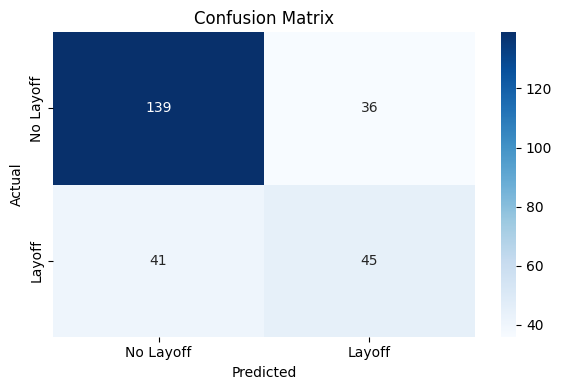

In [16]:
#evaluation

y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:,1]

print("Classification Report")
print(classification_report(y_test, y_pred))
print(f"Roc_Auc {roc_auc_score(y_test, y_pred)}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Layoff', 'Layoff'],
            yticklabels=['No Layoff', 'Layoff'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [17]:
xgb_model = best_pipeline.named_steps['model']

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)
print(f"SHAP values shape: {shap_values.shape}")
print("Explainer created successfully")


SHAP values shape: (261, 7)
Explainer created successfully


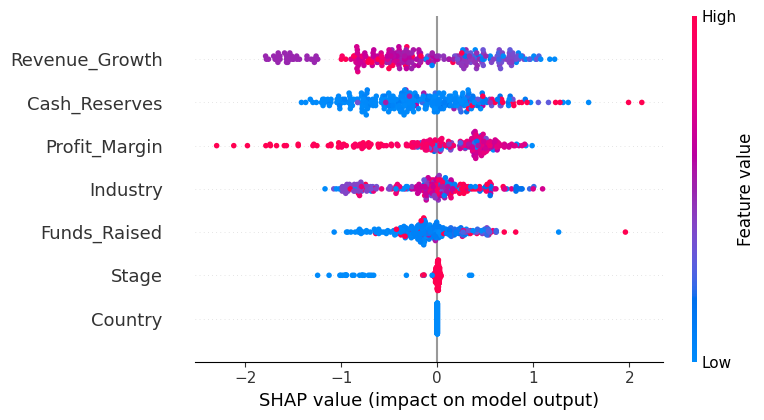

In [18]:
plt.figure()
shap.summary_plot(shap_values, X_test, show = True)

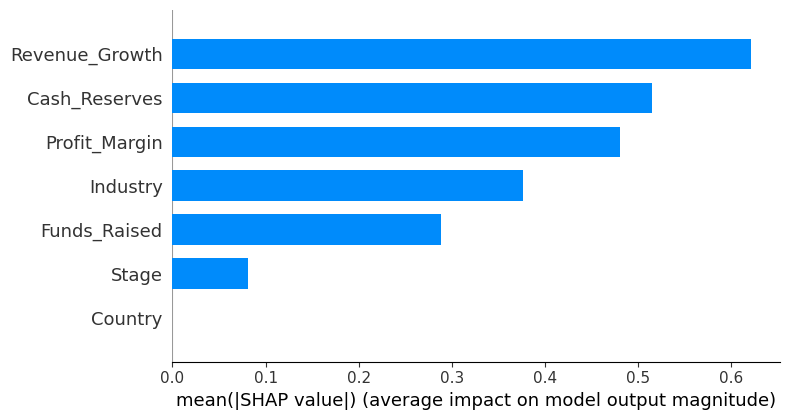

In [19]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type = 'bar', show = True)

In [20]:
with open("../models/xgb_best_model.pkl", 'wb') as f:
    pickle.dump(best_pipeline, f)

with open("../models/shap_explainer.pkl", 'wb') as f:
    pickle.dump(explainer, f)

In [21]:
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'

mlflow.set_tracking_uri(os.path.abspath('../mlruns'))
mlflow.set_experiment('layoff-early-warning')

with mlflow.start_run(run_name='xgb_smote_final'):
    
    # Log parameters
    mlflow.log_params({
        'model': 'XGBClassifier',
        'learning_rate': 0.05,
        'max_depth': 4,
        'min_child_weight': 1,
        'n_estimators': 300,
        'subsample': 1.0,
        'imbalance_strategy': 'SMOTE',
        'train_size': len(X_train),
        'test_size': len(X_test)
    })
    
    # Log metrics
    mlflow.log_metric('f1_score', f1_score(y_test, y_pred))
    mlflow.log_metric('roc_auc', roc_auc_score(y_test, y_prob))
    
    # Log model
    mlflow.sklearn.log_model(best_pipeline, 'model')
    
    print("Logged to MLflow successfully")
    print(f"F1: {f1_score(y_test, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

2026/06/02 18:43:18 INFO mlflow.tracking.fluent: Experiment with name 'layoff-early-warning' does not exist. Creating a new experiment.
2026/06/02 18:43:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/02 18:43:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged to MLflow successfully
F1: 0.5389
ROC-AUC: 0.7047
